In [1]:
import requests
import os
import datetime as dt
import json
from google.cloud import storage
from google.cloud import bigquery 
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely import wkt

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
bucket_name = os.environ.get("GCS_BUCKET_NAME")
service_acct = os.environ.get("GCS_BUCKET_CREDENTIALS")

GSclient = storage.Client.from_service_account_json(service_acct)
bucket = GSclient.bucket(bucket_name)

In [4]:
query_date = '2026-07-22'
blob = bucket.blob(f'{query_date}_rentals_api_call')
json_string = blob.download_as_text()
june11 = json.loads(json_string)

In [5]:
june11

[{'id': '669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109',
  'formattedAddress': '669 Ellis St, Apt 7, San Francisco, CA 94109',
  'addressLine1': '669 Ellis St',
  'addressLine2': 'Apt 7',
  'city': 'San Francisco',
  'state': 'CA',
  'stateFips': '06',
  'zipCode': '94109',
  'county': 'San Francisco',
  'countyFips': '075',
  'latitude': 37.7841,
  'longitude': -122.41713,
  'propertyType': 'Apartment',
  'bedrooms': 0,
  'bathrooms': 1,
  'status': 'Active',
  'price': 1895,
  'listingType': 'Standard',
  'listedDate': '2026-07-22T00:00:00.000Z',
  'removedDate': None,
  'createdDate': '2024-06-01T00:00:00.000Z',
  'lastSeenDate': '2026-07-22T02:25:59.177Z',
  'daysOnMarket': 1,
  'history': {'2024-12-08': {'event': 'Rental Listing',
    'price': 1895,
    'listingType': 'Standard',
    'listedDate': '2024-12-08T00:00:00.000Z',
    'removedDate': '2024-12-09T00:00:00.000Z',
    'daysOnMarket': 1},
   '2026-02-28': {'event': 'Rental Listing',
    'price': 1895,
    'listingType': 'Stan

In [6]:
df = pd.DataFrame(june11)
df.head()

,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,...,lastSeenDate,daysOnMarket,history,squareFootage,yearBuilt,lotSize,mlsName,mlsNumber,listingAgent,listingOffice
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",669 Ellis St,Apt 7,San Francisco,CA,06,94109,San Francisco,075,...,2026-07-22T02:25:59.177Z,1,"{'2024-12-08': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"20-Jennifer-Pl,-San-Francisco,-CA-94107","20 Jennifer Pl, San Francisco, CA 94107",20 Jennifer Pl,NaN,San Francisco,CA,06,94107,San Francisco,075,...,2026-07-22T02:25:59.177Z,1,"{'2026-07-22': {'event': 'Rental Listing', 'pr...",1367.0,NaN,NaN,NaN,NaN,NaN,NaN
2,"1160-Mission-St,-Unit-2003,-San-Francisco,-CA-...","1160 Mission St, Unit 2003, San Francisco, CA ...",1160 Mission St,Unit 2003,San Francisco,CA,06,94103,San Francisco,075,...,2026-07-22T02:25:59.176Z,1,"{'2026-07-22': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"1906-Mission-St,---206,-San-Francisco,-CA-94103","1906 Mission St, # 206, San Francisco, CA 94103",1906 Mission St,# 206,San Francisco,CA,06,94103,San Francisco,075,...,2026-07-22T02:25:59.175Z,1,"{'2025-04-06': {'event': 'Rental Listing', 'pr...",100.0,NaN,NaN,NaN,NaN,NaN,NaN
4,"85-Carl-St,-Apt-6,-San-Francisco,-CA-94117","85 Carl St, Apt 6, San Francisco, CA 94117",85 Carl St,Apt 6,San Francisco,CA,06,94117,San Francisco,075,...,2026-07-22T02:25:59.175Z,1,"{'2026-07-22': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['id', 'formattedAddress', 'addressLine1', 'addressLine2', 'city',
       'state', 'stateFips', 'zipCode', 'county', 'countyFips', 'latitude',
       'longitude', 'propertyType', 'bedrooms', 'bathrooms', 'status', 'price',
       'listingType', 'listedDate', 'removedDate', 'createdDate',
       'lastSeenDate', 'daysOnMarket', 'history', 'squareFootage', 'yearBuilt',
       'lotSize', 'mlsName', 'mlsNumber', 'listingAgent', 'listingOffice'],
      dtype='str')

In [8]:
df['history'][0]

{'2024-12-08': {'event': 'Rental Listing',
  'price': 1895,
  'listingType': 'Standard',
  'listedDate': '2024-12-08T00:00:00.000Z',
  'removedDate': '2024-12-09T00:00:00.000Z',
  'daysOnMarket': 1},
 '2026-02-28': {'event': 'Rental Listing',
  'price': 1895,
  'listingType': 'Standard',
  'listedDate': '2026-02-28T00:00:00.000Z',
  'removedDate': '2026-03-01T00:00:00.000Z',
  'daysOnMarket': 1},
 '2026-07-22': {'event': 'Rental Listing',
  'price': 1895,
  'listingType': 'Standard',
  'listedDate': '2026-07-22T00:00:00.000Z',
  'removedDate': None,
  'daysOnMarket': 1}}

In [9]:
test = df['history'][0]
pd.DataFrame.from_dict(test, orient='index').rename_axis('date').reset_index()

,date,event,price,listingType,listedDate,removedDate,daysOnMarket
0,2024-12-08,Rental Listing,1895,Standard,2024-12-08T00:00:00.000Z,2024-12-09T00:00:00.000Z,1
1,2026-02-28,Rental Listing,1895,Standard,2026-02-28T00:00:00.000Z,2026-03-01T00:00:00.000Z,1
2,2026-07-22,Rental Listing,1895,Standard,2026-07-22T00:00:00.000Z,NaN,1


In [10]:
df_histories = pd.DataFrame.from_dict(test, orient='index').rename_axis('date').reset_index()

In [11]:
hist_list = []
for h in df['history']:
    hist = pd.DataFrame.from_dict(h, orient='index').rename_axis('date').reset_index()
    hist_list.append(hist)


In [12]:
def dict_to_list(d):
    if not isinstance(d, dict): 
        return []
    return [{**value, 'event_date': key} for key, value in d.items()]

df['history_list'] = df['history'].apply(dict_to_list)
df_exploded = df.explode('history_list')
history_expanded = pd.json_normalize(df_exploded['history_list']).set_index(df_exploded.index)
final_df = pd.concat([df_exploded.drop(columns=['history', 'history_list']), history_expanded], axis=1)

In [13]:
final_df

,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,...,mlsNumber,listingAgent,listingOffice,event,price,listingType,listedDate,removedDate,daysOnMarket,event_date
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",669 Ellis St,Apt 7,San Francisco,CA,06,94109,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,1895,Standard,2024-12-08T00:00:00.000Z,2024-12-09T00:00:00.000Z,1,2024-12-08
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",669 Ellis St,Apt 7,San Francisco,CA,06,94109,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,1895,Standard,2026-02-28T00:00:00.000Z,2026-03-01T00:00:00.000Z,1,2026-02-28
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",669 Ellis St,Apt 7,San Francisco,CA,06,94109,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,1895,Standard,2026-07-22T00:00:00.000Z,NaN,1,2026-07-22
1,"20-Jennifer-Pl,-San-Francisco,-CA-94107","20 Jennifer Pl, San Francisco, CA 94107",20 Jennifer Pl,NaN,San Francisco,CA,06,94107,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,4999,Standard,2026-07-22T00:00:00.000Z,NaN,1,2026-07-22
2,"1160-Mission-St,-Unit-2003,-San-Francisco,-CA-...","1160 Mission St, Unit 2003, San Francisco, CA ...",1160 Mission St,Unit 2003,San Francisco,CA,06,94103,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,3995,Standard,2026-07-22T00:00:00.000Z,NaN,1,2026-07-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,"363-6th-St,-San-Francisco,-CA-94103","363 6th St, San Francisco, CA 94103",363 6th St,NaN,San Francisco,CA,06,94103,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,2920,Standard,2024-04-12T00:00:00.000Z,NaN,832,2024-04-12
497,"1348-Sacramento-St,-San-Francisco,-CA-94109","1348 Sacramento St, San Francisco, CA 94109",1348 Sacramento St,NaN,San Francisco,CA,06,94109,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,3595,Standard,2025-10-18T00:00:00.000Z,NaN,278,2025-10-18
498,"1301-16th-St,-San-Francisco,-CA-94103","1301 16th St, San Francisco, CA 94103",1301 16th St,NaN,San Francisco,CA,06,94103,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,5341,Standard,2025-02-14T00:00:00.000Z,NaN,524,2025-02-14
499,"830-Eddy-St,-San-Francisco,-CA-94109","830 Eddy St, San Francisco, CA 94109",830 Eddy St,NaN,San Francisco,CA,06,94109,San Francisco,075,...,NaN,NaN,NaN,Rental Listing,2810,Standard,2024-06-11T00:00:00.000Z,2025-09-07T00:00:00.000Z,453,2024-06-11


In [14]:
final_df.columns

Index(['id', 'formattedAddress', 'addressLine1', 'addressLine2', 'city',
       'state', 'stateFips', 'zipCode', 'county', 'countyFips', 'latitude',
       'longitude', 'propertyType', 'bedrooms', 'bathrooms', 'status', 'price',
       'listingType', 'listedDate', 'removedDate', 'createdDate',
       'lastSeenDate', 'daysOnMarket', 'squareFootage', 'yearBuilt', 'lotSize',
       'mlsName', 'mlsNumber', 'listingAgent', 'listingOffice', 'event',
       'price', 'listingType', 'listedDate', 'removedDate', 'daysOnMarket',
       'event_date'],
      dtype='str')

In [15]:
final_df = final_df[['id', 'formattedAddress', 'latitude', 'longitude', 'propertyType', 'bedrooms', 'bathrooms',
                  'squareFootage', 'status', 'price', 'listedDate', 'removedDate']].copy()

In [16]:
gdf = gpd.GeoDataFrame(final_df, geometry=gpd.points_from_xy(final_df['longitude'], final_df['latitude']), crs='EPSG:4326')
gdf.head()

,id,formattedAddress,latitude,longitude,propertyType,bedrooms,bathrooms,squareFootage,status,price,price,listedDate,listedDate,removedDate,removedDate,geometry
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",37.784100,-122.417130,Apartment,0.0,1.0,NaN,Active,1895,1895,2026-07-22T00:00:00.000Z,2024-12-08T00:00:00.000Z,None,2024-12-09T00:00:00.000Z,POINT (-122.41713 37.7841)
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",37.784100,-122.417130,Apartment,0.0,1.0,NaN,Active,1895,1895,2026-07-22T00:00:00.000Z,2026-02-28T00:00:00.000Z,None,2026-03-01T00:00:00.000Z,POINT (-122.41713 37.7841)
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",37.784100,-122.417130,Apartment,0.0,1.0,NaN,Active,1895,1895,2026-07-22T00:00:00.000Z,2026-07-22T00:00:00.000Z,None,NaN,POINT (-122.41713 37.7841)
1,"20-Jennifer-Pl,-San-Francisco,-CA-94107","20 Jennifer Pl, San Francisco, CA 94107",37.780015,-122.402332,Single Family,2.0,1.0,1367.0,Active,4999,4999,2026-07-22T00:00:00.000Z,2026-07-22T00:00:00.000Z,None,NaN,POINT (-122.40233 37.78002)
2,"1160-Mission-St,-Unit-2003,-San-Francisco,-CA-...","1160 Mission St, Unit 2003, San Francisco, CA ...",37.778724,-122.412662,Condo,1.0,1.0,NaN,Active,3995,3995,2026-07-22T00:00:00.000Z,2026-07-22T00:00:00.000Z,None,NaN,POINT (-122.41266 37.77872)


In [17]:
def pull_bucket_file(bucket_name: str, query_date:str):
    """query_date should be formatted as YYYY-MM-DD"""
    
    GSclient = storage.Client()
    bucket = GSclient.bucket(bucket_name)
    blob = bucket.blob(f'{query_date}_rentals_api_call')
    text = blob.download_as_text()
    
    return pd.DataFrame(json.loads(text))

def pull_bigquery_table(table_name: str):
    """Careful!! This pulls the ENTIRE table, so watch out!"""
    
    BQclient = bigquery.Client()
    query = f'''SELECT * 
            FROM `neighboorhood-nachos.neighborhood_livability_data.{table_name}`'''
    
    return BQclient.query(query).to_dataframe()

def format_bqtable_to_gdf(df):
    df['geometry'] = df['geometry'].apply(wkt.loads)
    return gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

In [18]:
df_neighborhoods = pull_bigquery_table('neighborhoods')
gdf_neighborhoods = format_bqtable_to_gdf(df_neighborhoods)
gdf_neighborhoods.columns = ['neighborhood_id', 'name', 'geometry']

df_policedistricts = pull_bigquery_table('police_districts')
gdf_policedistricts = format_bqtable_to_gdf(df_policedistricts)
gdf_policedistricts.columns = ['police_district_id', 'name', 'geometry']

/opt/anaconda3/envs/env_transform_311/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/opt/anaconda3/envs/env_transform_311/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


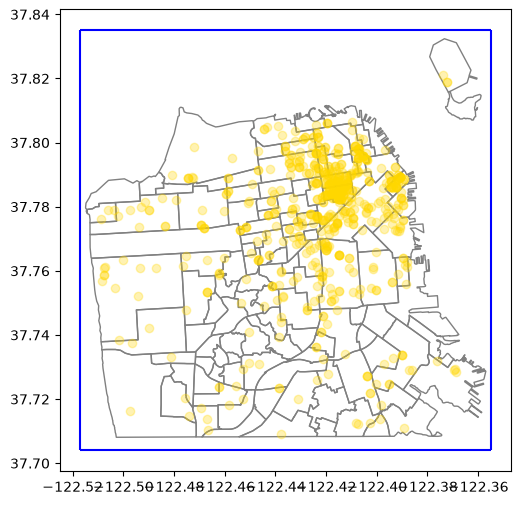

In [19]:
fig, ax = plt.subplots(figsize=(6,6))
gdf_neighborhoods.plot(ax=ax, facecolor='none', edgecolor='grey')
gdf.plot(ax=ax, color='gold', alpha=.3)
ax.vlines(-122.517, 37.704, 37.835, colors='blue')
ax.vlines(-122.355, 37.704, 37.835, colors='blue')
ax.hlines(37.835, -122.517, -122.355, colors='blue')
ax.hlines(37.704, -122.517, -122.355, colors='blue')

plt.show()

In [20]:
gdf[gdf['longitude'] > -122.35] #interesting, do we take the lat/long or the address? probably address

,id,formattedAddress,latitude,longitude,propertyType,bedrooms,bathrooms,squareFootage,status,price,price,listedDate,listedDate,removedDate,removedDate,geometry


In [21]:
df[df['history'].isna()]

,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,...,daysOnMarket,history,squareFootage,yearBuilt,lotSize,mlsName,mlsNumber,listingAgent,listingOffice,history_list


In [22]:
history_expanded

,event,price,listingType,listedDate,removedDate,daysOnMarket,event_date
0,Rental Listing,1895,Standard,2024-12-08T00:00:00.000Z,2024-12-09T00:00:00.000Z,1,2024-12-08
0,Rental Listing,1895,Standard,2026-02-28T00:00:00.000Z,2026-03-01T00:00:00.000Z,1,2026-02-28
0,Rental Listing,1895,Standard,2026-07-22T00:00:00.000Z,NaN,1,2026-07-22
1,Rental Listing,4999,Standard,2026-07-22T00:00:00.000Z,NaN,1,2026-07-22
2,Rental Listing,3995,Standard,2026-07-22T00:00:00.000Z,NaN,1,2026-07-22
...,...,...,...,...,...,...,...
496,Rental Listing,2920,Standard,2024-04-12T00:00:00.000Z,NaN,832,2024-04-12
497,Rental Listing,3595,Standard,2025-10-18T00:00:00.000Z,NaN,278,2025-10-18
498,Rental Listing,5341,Standard,2025-02-14T00:00:00.000Z,NaN,524,2025-02-14
499,Rental Listing,2810,Standard,2024-06-11T00:00:00.000Z,2025-09-07T00:00:00.000Z,453,2024-06-11


In [23]:
df_exploded

,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,...,daysOnMarket,history,squareFootage,yearBuilt,lotSize,mlsName,mlsNumber,listingAgent,listingOffice,history_list
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",669 Ellis St,Apt 7,San Francisco,CA,06,94109,San Francisco,075,...,1,"{'2024-12-08': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 1895, 'li..."
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",669 Ellis St,Apt 7,San Francisco,CA,06,94109,San Francisco,075,...,1,"{'2024-12-08': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 1895, 'li..."
0,"669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109","669 Ellis St, Apt 7, San Francisco, CA 94109",669 Ellis St,Apt 7,San Francisco,CA,06,94109,San Francisco,075,...,1,"{'2024-12-08': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 1895, 'li..."
1,"20-Jennifer-Pl,-San-Francisco,-CA-94107","20 Jennifer Pl, San Francisco, CA 94107",20 Jennifer Pl,NaN,San Francisco,CA,06,94107,San Francisco,075,...,1,"{'2026-07-22': {'event': 'Rental Listing', 'pr...",1367.0,NaN,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 4999, 'li..."
2,"1160-Mission-St,-Unit-2003,-San-Francisco,-CA-...","1160 Mission St, Unit 2003, San Francisco, CA ...",1160 Mission St,Unit 2003,San Francisco,CA,06,94103,San Francisco,075,...,1,"{'2026-07-22': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 3995, 'li..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,"363-6th-St,-San-Francisco,-CA-94103","363 6th St, San Francisco, CA 94103",363 6th St,NaN,San Francisco,CA,06,94103,San Francisco,075,...,832,"{'2024-04-12': {'event': 'Rental Listing', 'pr...",370.0,2020.0,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 2920, 'li..."
497,"1348-Sacramento-St,-San-Francisco,-CA-94109","1348 Sacramento St, San Francisco, CA 94109",1348 Sacramento St,NaN,San Francisco,CA,06,94109,San Francisco,075,...,278,"{'2025-10-18': {'event': 'Rental Listing', 'pr...",NaN,1922.0,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 3595, 'li..."
498,"1301-16th-St,-San-Francisco,-CA-94103","1301 16th St, San Francisco, CA 94103",1301 16th St,NaN,San Francisco,CA,06,94103,San Francisco,075,...,524,"{'2025-02-14': {'event': 'Rental Listing', 'pr...",570.0,2020.0,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 5341, 'li..."
499,"830-Eddy-St,-San-Francisco,-CA-94109","830 Eddy St, San Francisco, CA 94109",830 Eddy St,NaN,San Francisco,CA,06,94109,San Francisco,075,...,316,"{'2024-06-11': {'event': 'Rental Listing', 'pr...",461.0,2021.0,NaN,NaN,NaN,NaN,NaN,"{'event': 'Rental Listing', 'price': 2810, 'li..."


In [24]:
df['price'][499]

np.int64(3518)

In [25]:
df['history'][499]

{'2024-06-11': {'event': 'Rental Listing',
  'price': 2810,
  'listingType': 'Standard',
  'listedDate': '2024-06-11T00:00:00.000Z',
  'removedDate': '2025-09-07T00:00:00.000Z',
  'daysOnMarket': 453},
 '2025-09-10': {'event': 'Rental Listing',
  'price': 3518,
  'listingType': 'Standard',
  'listedDate': '2025-09-10T00:00:00.000Z',
  'removedDate': None,
  'daysOnMarket': 316}}

In [26]:
def format_bucket_to_gdf(df):
    
    def dict_to_list(d):
        if not isinstance(d, dict): 
            return []
        return [{**value, 'event_date': key} for key, value in d.items()]
    
    df1 = df.drop(columns=['removedDate', 'listedDate', 'price'])
    gdf = gpd.GeoDataFrame(df1, geometry=gpd.points_from_xy(df1['longitude'], df1['latitude']), crs='EPSG:4326')

    gdf['history_list'] = gdf['history'].apply(dict_to_list)
    gdf_exploded = gdf.explode('history_list')
    history_expanded = pd.json_normalize(gdf_exploded['history_list']).set_index(gdf_exploded.index)
    final_gdf = pd.concat([gdf_exploded.drop(columns=['history', 'history_list']), history_expanded], axis=1)

    mask = ((final_gdf['longitude'] > -122.355) | (final_gdf['longitude'] < -122.517) | (final_gdf['latitude'] > 37.835) | (final_gdf['latitude'] < 37.704))
    if mask.any():
        geocodes = gpd.tools.geocode(final_gdf.loc[mask, 'formattedAddress'], provider='arcgis')
        final_gdf.loc[mask, 'geometry'] = geocodes['geometry']
    if mask.any:
        final_gdf = final_gdf.drop(final_gdf[mask].index)
    return final_gdf

def add_ids_to_gdf(gdf, neighborhoods, police_districts):
    gdf1 = gpd.sjoin(gdf, police_districts[['police_district_id', 'geometry']], how='left', predicate='within')
    gdf1.drop(columns=['index_right'], inplace=True)
    gdf2 = gpd.sjoin(gdf1, neighborhoods[['neighborhood_id', 'geometry']], how='left', predicate='within')

    gdf2['neighborhood_id'] = gdf2['neighborhood_id'].fillna(404)
    gdf2['police_district_id'] = gdf2['police_district_id'].fillna(404)

    return gdf2

In [27]:
gdf = format_bucket_to_gdf(df)

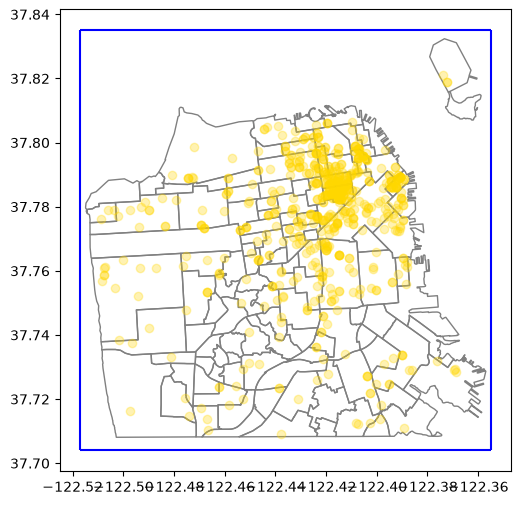

In [28]:
fig, ax = plt.subplots(figsize=(6,6))
gdf_neighborhoods.plot(ax=ax, facecolor='none', edgecolor='grey')
gdf.plot(ax=ax, color='gold', alpha=.3)
ax.vlines(-122.517, 37.704, 37.835, colors='blue')
ax.vlines(-122.355, 37.704, 37.835, colors='blue')
ax.hlines(37.835, -122.517, -122.355, colors='blue')
ax.hlines(37.704, -122.517, -122.355, colors='blue')

plt.show()

In [ ]:
mask = ((gdf['longitude'] > -122.355) | (gdf['longitude'] < -122.517) | (gdf['latitude'] > 37.835) | (gdf['latitude'] < 37.704))

gdf[mask]['formattedAddress'] #okay the issue is actually after looking it up that these addys ARE IN FACT not in SF but in Oakland, as their originial lat/long suggested

0    5412 Claremont Ave, Apt 17, San Francisco, CA ...
1    5412 Claremont Ave, Apt 34, San Francisco, CA ...
Name: formattedAddress, dtype: str

In [95]:
gdf.drop(gdf[mask].index)

,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,...,daysOnMarket,history,yearBuilt,lotSize,mlsName,mlsNumber,listingAgent,listingOffice,history_list,geometry
2,"2033-Castro-St,-Apt-11,-San-Francisco,-CA-94131","2033 Castro St, Apt 11, San Francisco, CA 94131",2033 Castro St,Apt 11,San Francisco,CA,06,94131,San Francisco,075,...,1,"{'2026-05-30': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 4995, 'l...",POINT (-122.43298 37.74516)
3,"960-Market-St,-Unit-1001,-San-Francisco,-CA-94102","960 Market St, Unit 1001, San Francisco, CA 94102",960 Market St,Unit 1001,San Francisco,CA,06,94102,San Francisco,075,...,1,"{'2026-06-11': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 4295, 'l...",POINT (-122.41008 37.78306)
4,"3665A-20th-St,-San-Francisco,-CA-94110","3665A 20th St, San Francisco, CA 94110",3665A 20th St,NaN,San Francisco,CA,06,94110,San Francisco,075,...,1,"{'2026-06-11': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 4995, 'l...",POINT (-122.42272 37.75817)
5,"920-Taylor-St,-Apt-8,-San-Francisco,-CA-94108","920 Taylor St, Apt 8, San Francisco, CA 94108",920 Taylor St,Apt 8,San Francisco,CA,06,94108,San Francisco,075,...,1,"{'2026-06-11': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 4995, 'l...",POINT (-122.41203 37.79107)
6,"1426-Stockton-St,-San-Francisco,-CA-94133","1426 Stockton St, San Francisco, CA 94133",1426 Stockton St,NaN,San Francisco,CA,06,94133,San Francisco,075,...,1,"{'2025-06-18': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 3100, 'l...",POINT (-122.40855 37.79888)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,"779-783-Guerrero-St,-San-Francisco,-CA-94110","779 783 Guerrero St, San Francisco, CA 94110",779 783 Guerrero St,NaN,San Francisco,CA,06,94110,San Francisco,075,...,3,"{'2025-08-01': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 3800, 'l...",POINT (-122.4234 37.75874)
496,"1346-Pine-St,-San-Francisco,-CA-94109","1346 Pine St, San Francisco, CA 94109",1346 Pine St,NaN,San Francisco,CA,06,94109,San Francisco,075,...,4,"{'2025-01-03': {'event': 'Rental Listing', 'pr...",1910.0,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 2499, 'l...",POINT (-122.41794 37.79023)
497,"3937-Irving-St,-San-Francisco,-CA-94122","3937 Irving St, San Francisco, CA 94122",3937 Irving St,NaN,San Francisco,CA,06,94122,San Francisco,075,...,3,"{'2026-06-09': {'event': 'Rental Listing', 'pr...",NaN,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 2800, 'l...",POINT (-122.50025 37.76234)
498,"101-Polk-St,-San-Francisco,-CA-94102","101 Polk St, San Francisco, CA 94102",101 Polk St,NaN,San Francisco,CA,06,94102,San Francisco,075,...,16,"{'2026-05-27': {'event': 'Rental Listing', 'pr...",2016.0,NaN,NaN,NaN,NaN,NaN,"[{'event': 'Rental Listing', 'price': 4284, 'l...",POINT (-122.4184 37.77773)


In [97]:
def dict_to_list(d):
    if not isinstance(d, dict): 
        return []
    return [{**value, 'event_date': key} for key, value in d.items()]

gdf['history_list'] = gdf['history'].apply(dict_to_list)
gdf_exploded = gdf.explode('history_list')
history_expanded = pd.json_normalize(gdf_exploded['history_list']).set_index(gdf_exploded.index)
final_gdf = pd.concat([gdf_exploded.drop(columns=['history', 'history_list']), history_expanded], axis=1)

In [208]:
df = pull_bucket_file(bucket_name, '2026-06-11')
gdf = format_bucket_to_gdf(df)
gdf_final = add_ids_to_gdf(gdf, gdf_neighborhoods, gdf_policedistricts)

In [209]:
gdf_final[gdf_final['police_district_id'] == 404]

,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,...,event,price,listingType,listedDate,removedDate,daysOnMarket,event_date,police_district_id,index_right,neighborhood_id
140,"1569-Pershing-Dr,-Apt-G,-San-Francisco,-CA-94129","1569 Pershing Dr, Apt G, San Francisco, CA 94129",1569 Pershing Dr,Apt G,San Francisco,CA,06,94129,San Francisco,075,...,Rental Listing,4800,Standard,2022-09-29T00:00:00.000Z,NaN,1352,2022-09-29,404,3,3
142,"812-Quarry-Rd,-Apt-B,-San-Francisco,-CA-94129","812 Quarry Rd, Apt B, San Francisco, CA 94129",812 Quarry Rd,Apt B,San Francisco,CA,06,94129,San Francisco,075,...,Rental Listing,4990,Standard,2023-11-01T00:00:00.000Z,NaN,954,2023-11-01,404,3,3
151,"1711-Baker-Ct,-Apt-B,-San-Francisco,-CA-94129","1711 Baker Ct, Apt B, San Francisco, CA 94129",1711 Baker Ct,Apt B,San Francisco,CA,06,94129,San Francisco,075,...,Rental Listing,5200,Standard,2022-11-02T00:00:00.000Z,NaN,1318,2022-11-02,404,3,3
212,"1801-Wedemeyer-St,-Unit-312,-San-Francisco,-CA...","1801 Wedemeyer St, Unit 312, San Francisco, CA...",1801 Wedemeyer St,Unit 312,San Francisco,CA,06,94129,San Francisco,075,...,Rental Listing,4850,Standard,2025-12-19T00:00:00.000Z,NaN,175,2025-12-19,404,3,3
359,"1801-Wedemeyer-St,-San-Francisco,-CA-94129","1801 Wedemeyer St, San Francisco, CA 94129",1801 Wedemeyer St,NaN,San Francisco,CA,06,94129,San Francisco,075,...,Rental Listing,3779,Standard,2025-06-30T00:00:00.000Z,2025-12-16T00:00:00.000Z,169,2025-06-30,404,3,3
359,"1801-Wedemeyer-St,-San-Francisco,-CA-94129","1801 Wedemeyer St, San Francisco, CA 94129",1801 Wedemeyer St,NaN,San Francisco,CA,06,94129,San Francisco,075,...,Rental Listing,4200,Standard,2026-01-22T00:00:00.000Z,NaN,141,2026-01-22,404,3,3


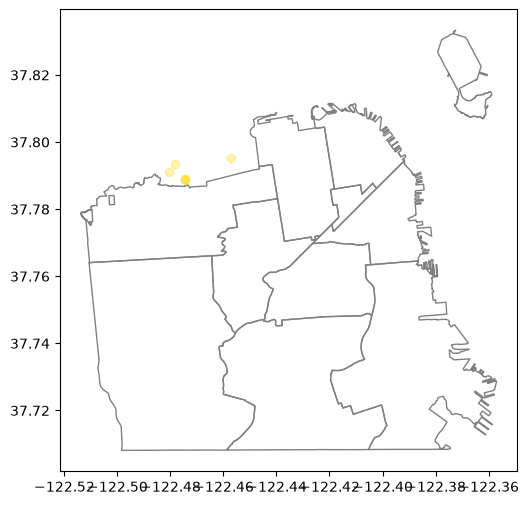

In [210]:
fig, ax = plt.subplots(figsize=(6,6))
gdf_policedistricts.plot(ax=ax, facecolor='none', edgecolor='grey')
gdf_final[gdf_final['police_district_id'] == 404].plot(ax=ax, color='gold', alpha=.3)

plt.show() #ahhh yes the presidio, this is fine

In [211]:
for key, value in gdf_final['id'].value_counts().items():
    if value > 1:
        print(key, value)

2023-Folsom-St,-San-Francisco,-CA-94110 5
1426-Stockton-St,-San-Francisco,-CA-94133 4
319-Ivy-St,---413,-San-Francisco,-CA-94102 4
333-Beale-St,-Apt-6J,-San-Francisco,-CA-94105 4
901-Pine-St,-San-Francisco,-CA-94108 3
1220-Hayes-St,-Apt-1,-San-Francisco,-CA-94117 3
422-Ellis-St,-Unit-404,-San-Francisco,-CA-94102 3
833-Kearny-St,-Unit-31,-San-Francisco,-CA-94108 3
1906-Mission-St,---206,-San-Francisco,-CA-94103 3
669-Ellis-St,-Apt-7,-San-Francisco,-CA-94109 3
1461-Broadway,-San-Francisco,-CA-94109 3
1077-Ashbury-St,-San-Francisco,-CA-94117 3
1825-Mission-St,-San-Francisco,-CA-94103 3
150-Van-Ness-Ave,-Apt-1222,-San-Francisco,-CA-94102 3
1572-Palou-Ave,-San-Francisco,-CA-94124 3
338-Main-St,-Unit-18H,-San-Francisco,-CA-94105 3
635-Ellis-St,-San-Francisco,-CA-94109 3
479-35th-Ave,-San-Francisco,-CA-94121 3
1440-Sutter-St,-San-Francisco,-CA-94109 3
737-Bush-St,-San-Francisco,-CA-94108 3
300-Monterey-Blvd,-San-Francisco,-CA-94131 3
99-Ocean-Ave,-San-Francisco,-CA-94112 3
77-Bruton-St,-San-F

In [212]:
gdf_final[gdf_final['id'] == '2023-Folsom-St,-San-Francisco,-CA-94110']

,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,...,event,price,listingType,listedDate,removedDate,daysOnMarket,event_date,police_district_id,index_right,neighborhood_id
68,"2023-Folsom-St,-San-Francisco,-CA-94110","2023 Folsom St, San Francisco, CA 94110",2023 Folsom St,NaN,San Francisco,CA,06,94110,San Francisco,075,...,Rental Listing,2625,Standard,2023-07-09T00:00:00.000Z,2025-08-10T00:00:00.000Z,763,2023-07-09,3,53,53
68,"2023-Folsom-St,-San-Francisco,-CA-94110","2023 Folsom St, San Francisco, CA 94110",2023 Folsom St,NaN,San Francisco,CA,06,94110,San Francisco,075,...,Rental Listing,2495,Standard,2025-12-12T00:00:00.000Z,2025-12-13T00:00:00.000Z,1,2025-12-12,3,53,53
68,"2023-Folsom-St,-San-Francisco,-CA-94110","2023 Folsom St, San Francisco, CA 94110",2023 Folsom St,NaN,San Francisco,CA,06,94110,San Francisco,075,...,Rental Listing,2395,Standard,2025-12-20T00:00:00.000Z,2026-01-18T00:00:00.000Z,29,2025-12-20,3,53,53
68,"2023-Folsom-St,-San-Francisco,-CA-94110","2023 Folsom St, San Francisco, CA 94110",2023 Folsom St,NaN,San Francisco,CA,06,94110,San Francisco,075,...,Rental Listing,2695,Standard,2026-05-04T00:00:00.000Z,2026-06-07T00:00:00.000Z,34,2026-05-04,3,53,53
68,"2023-Folsom-St,-San-Francisco,-CA-94110","2023 Folsom St, San Francisco, CA 94110",2023 Folsom St,NaN,San Francisco,CA,06,94110,San Francisco,075,...,Rental Listing,2495,Standard,2026-06-11T00:00:00.000Z,NaN,1,2026-06-11,3,53,53


In [214]:
gdf_final['price']

2      4995
2      4995
3      4295
4      4995
5      4995
       ... 
496    2499
496    2499
497    2800
498    4284
499    3629
Name: price, Length: 649, dtype: int64

In [215]:
gdf_final.columns

Index(['id', 'formattedAddress', 'addressLine1', 'addressLine2', 'city',
       'state', 'stateFips', 'zipCode', 'county', 'countyFips', 'latitude',
       'longitude', 'propertyType', 'bedrooms', 'bathrooms', 'squareFootage',
       'status', 'listingType', 'createdDate', 'lastSeenDate', 'daysOnMarket',
       'yearBuilt', 'lotSize', 'mlsName', 'mlsNumber', 'listingAgent',
       'listingOffice', 'geometry', 'event', 'price', 'listingType',
       'listedDate', 'removedDate', 'daysOnMarket', 'event_date',
       'police_district_id', 'index_right', 'neighborhood_id'],
      dtype='str')

In [216]:
gdf_final = gdf_final[['id', 'listedDate', 'removedDate', 'neighborhood_id', 'police_district_id', 
                        'propertyType', 'bedrooms', 'bathrooms', 'squareFootage', 'status', 'price', 
                        'formattedAddress', 'latitude', 'longitude', 'geometry']].copy()
gdf_final = gdf_final.reset_index().drop(columns='index')

In [217]:
gdf_final[gdf_final['id'] == '2023-Folsom-St,-San-Francisco,-CA-94110']

,id,listedDate,removedDate,neighborhood_id,police_district_id,propertyType,bedrooms,bathrooms,squareFootage,status,price,formattedAddress,latitude,longitude,geometry
96,"2023-Folsom-St,-San-Francisco,-CA-94110",2023-07-09T00:00:00.000Z,2025-08-10T00:00:00.000Z,53,3,Single Family,1.0,1.0,336.0,Active,2625,"2023 Folsom St, San Francisco, CA 94110",37.764902,-122.414949,POINT (-122.41495 37.7649)
97,"2023-Folsom-St,-San-Francisco,-CA-94110",2025-12-12T00:00:00.000Z,2025-12-13T00:00:00.000Z,53,3,Single Family,1.0,1.0,336.0,Active,2495,"2023 Folsom St, San Francisco, CA 94110",37.764902,-122.414949,POINT (-122.41495 37.7649)
98,"2023-Folsom-St,-San-Francisco,-CA-94110",2025-12-20T00:00:00.000Z,2026-01-18T00:00:00.000Z,53,3,Single Family,1.0,1.0,336.0,Active,2395,"2023 Folsom St, San Francisco, CA 94110",37.764902,-122.414949,POINT (-122.41495 37.7649)
99,"2023-Folsom-St,-San-Francisco,-CA-94110",2026-05-04T00:00:00.000Z,2026-06-07T00:00:00.000Z,53,3,Single Family,1.0,1.0,336.0,Active,2695,"2023 Folsom St, San Francisco, CA 94110",37.764902,-122.414949,POINT (-122.41495 37.7649)
100,"2023-Folsom-St,-San-Francisco,-CA-94110",2026-06-11T00:00:00.000Z,NaN,53,3,Single Family,1.0,1.0,336.0,Active,2495,"2023 Folsom St, San Francisco, CA 94110",37.764902,-122.414949,POINT (-122.41495 37.7649)


In [238]:
def format_gdf_final_columns(gdf):
    gdf1 = gdf[['id', 'listedDate',  'removedDate', 'neighborhood_id', 'police_district_id', 
                'propertyType', 'bedrooms', 'bathrooms', 'squareFootage', 'status', 
                'price', 'formattedAddress', 'latitude', 'longitude', 'geometry']].copy()
    gdf1.columns = ['rentcast_id', 'listed_date',  'removed_date', 'neighborhood_id', 'police_district_id', 
                    'property_type', 'beds', 'baths', 'square_footage', 'status', 'price', 
                    'formatted_address', 'lat', 'long', 'geometry']
    
    gdf1['geometry'] = gdf1.geometry.to_wkt()

    timestamp_cols = ['listed_date', 'removed_date']
    for col in timestamp_cols:
        gdf1[col] = pd.to_datetime(gdf1[col]).dt.tz_convert('UTC')
    
    gdf1 = gdf1.astype(
    {'rentcast_id': str,
     'property_type': str,
     'beds': float,
     'baths': float,
     'square_footage': float,
     'status': str,
     'price': 'Int64',
     'formatted_address': str,
     'lat': float,
     'long': float})

    return gdf1

In [236]:
gdf_final.dtypes

id                         str
listedDate                 str
removedDate                str
neighborhood_id          Int64
police_district_id       Int64
propertyType               str
bedrooms               float64
bathrooms              float64
squareFootage          float64
status                     str
price                    int64
formattedAddress           str
latitude               float64
longitude              float64
geometry              geometry
dtype: object

In [228]:
gdf_final['geometry'].dtype

In [239]:
gdf_final = format_gdf_final_columns(gdf_final)

/var/folders/06/wr5z_lvj1gg8xf40dsck2zdm0000gn/T/ipykernel_26600/3527658091.py:9: UserWarning: Geometry column does not contain geometry.
  gdf1['geometry'] = gdf1.geometry.to_wkt()


In [240]:
gdf_final.dtypes

rentcast_id                           str
listed_date           datetime64[us, UTC]
removed_date          datetime64[us, UTC]
neighborhood_id                     Int64
police_district_id                  Int64
property_type                         str
beds                              float64
baths                             float64
square_footage                    float64
status                                str
price                               Int64
formatted_address                     str
lat                               float64
long                              float64
geometry                              str
dtype: object

In [244]:
gdf_final[gdf_final['price'].isna()]

,rentcast_id,listed_date,removed_date,neighborhood_id,police_district_id,property_type,beds,baths,square_footage,status,price,formatted_address,lat,long,geometry


In [246]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [247]:
len(gdf_final)

649